# Лабораторная работа №4

ФИО:   
Группа: 

Отправлять можно следующими способами:
1. Запушить этот ноутбук в GitHub в репозиторий, где у вас лежат ноутбуки с лабами

Deadlines:
- Занятие №8 в семестре (Занятие №4 очное)

Что необходимо сделать:  
- Обучить различные модели глубокого обучения на имеющихся данных  

---
## Читайте задание внимательно

Исходные данные:
1. В [табличке](https://docs.google.com/spreadsheets/d/11600OkqdRzxc-xZmFTuBs099VeAqU_GlE0Bx6bBlIRE/edit?usp=sharing) необходимо узнать название своего датасета 
2. Скачать нужны вам данные можно в [Google Drive](https://drive.google.com/drive/folders/1Phm-Fq1GL-VX7NS-DCEMRh_Fo1wU7DQ9?usp=sharing)
  
---
Теперь по пунктам, что я от вас жду:  
1. Загрузить необходимые данные к себе и считать (read) их в переменную.
2. Понять, у вас задача классификации (бинарной или многоклассовой) или регрессии.
3. Сделать предобработку данных:  
     1. Разделить выборку на тренировочную (train) и тестовую (test). _Обратите внимание, что обучать скейлеры и определять, какими значениями вы будете заполнять пропуски, вы будете на train выборке, а применять и на train, и на test_.
     2. Проверить пропуски в данных. Если они есть, заполнить одной из стратегий, предложенных в ноутбуке для семинара №3. P.S. Для численных и категориальных переменных будут разные стратегии.
     3. Отнормировать численные переменные (`StandardScaler`, `MinMaxScaler`).
     4. Закодировать категориальные признаки по одной из стратегий.
4. Оформить данные в виде класса `Dataset` из библиотеки `torch` (как мы это делали на семинаре), а затем засунуть в `Dataloader` (тоже делали на семинаре).
5. Обучить на тренировочном множестве:
     1. Очень простую однослойную нейросеть с оптимизатором `SGD` ([link](https://pytorch.org/docs/stable/optim.html)).
     2. Нейросеть посложнее (с 1 скрытым слоем) с оптимизатором `Adam` ([link](https://pytorch.org/docs/stable/optim.html)).
     3. Нейросеть еще сложнее (с 3+ скрытыми слоями) с оптимизатором `Adam` ([link](https://pytorch.org/docs/stable/optim.html)).
6. Посчитайте loss на train и test множествах, в зависимости от эпохи обучения. Провизуализируйте это с помощью библиотеки `matplotlib` (выйдет так называемая **learning curve**, кривая обучения модели).
6. Посчитайте метрики на train и test множествах:
     1. Для задачи классификации -- Accuracy
     2. Для задачи регрессии -- MAE
7. Сравните метрики относительно train/test, так и относительно разных моделей. Ответьте на следующие вопросы:
     1. Какая модель справилась лучше с поставленной задачей?
     2. Имеет ли место переобучение?
     3. Имеет ли место недообучение?
     4. Как можно улучшить метрики моделей?

---
P.S.  
Просьба -- делать каждое задание в отдельных ячейках и с отдельными заголовками (как пункт 1 и 2 в этом ноутбуке) типа  
- Заголовок
- Ячейки с кодом
- Другой заголовок
- Другие ячейки с кодом

P.S.S.  
Если вам повезло с многоклассовой классификацией, у вас не будет проблем, просто нужно будет поставить необходимое количество нейронов на выходе вашей нейросети.

## 1. Пример импорта данных. Грузим данные

In [37]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


data = pd.read_csv ("marketing_campaign.csv", sep='\t') # если нужно, можно поменять разделитель

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 2. Понимаем, какая перед нами задача

In [16]:
Классификация, каждый элемент данных( строка) содержит признаки и метку класса( 0 или 1), что указывает на то, что задача состоит в прогнозировании метки, класса для каждого наблюдения. В случае регрессии мы бы ожидали числовой выход, а не категориальный.

SyntaxError: invalid syntax (792773095.py, line 1)

## 3. Делаем предобработку данных

In [23]:
# Просмотр информации о данных
data.info()

# Просмотр статистики по данным
data.describe(include='all')

target = 'Response'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Разделение данных на признаки и целевую переменную
X = data.drop('Response', axis=1)
y = data['Response']

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Проверка пропусков в данных
missing_values = X_train.isnull().sum()

# Численные и категориальные признаки
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

# Пайплайн для численных признаков
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категориальных признаков
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Объединение пайплайнов
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Применение преобразований к тренировочным данным
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Проверка результатов предобработки
X_train_preprocessed.shape, X_test_preprocessed.shape


((1792, 679), (448, 679))

In [26]:
from sklearn.model_selection import train_test_split

# Разделение данных на признаки и целевую переменную
X = data.drop(columns=[target])
y = data[target]

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Проверка размеров выборок
print(f"Размеры X_train: {X_train.shape}")
print(f"Размеры X_test: {X_test.shape}")
print(f"Размеры y_train: {y_train.shape}")
print(f"Размеры y_test: {y_test.shape}")


Размеры X_train: (1792, 28)
Размеры X_test: (448, 28)
Размеры y_train: (1792,)
Размеры y_test: (448,)


In [31]:
# Проверка на наличие пропусков
missing_values = X_train.isnull().sum()
print("Пропущенные значения в X_train:")
print(missing_values[missing_values > 0])

from sklearn.impute import SimpleImputer

# Для числовых данных
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
imputer_num = SimpleImputer(strategy='mean')
X_train[numerical_features] = imputer_num.fit_transform(X_train[numerical_features])
X_test[numerical_features] = imputer_num.transform(X_test[numerical_features])

# Для категориальных данных
categorical_features = X_train.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[categorical_features] = imputer_cat.fit_transform(X_train[categorical_features])
X_test[categorical_features] = imputer_cat.transform(X_test[categorical_features])



Пропущенные значения в X_train:
Series([], dtype: int64)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

from sklearn.preprocessing import OneHotEncoder

# Удалим колонку с датами из категориальных признаков
date_columns = ['Dt_Customer']  # Замените на фактические названия колонок с датами, если их больше
categorical_features = categorical_features.difference(date_columns)

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# Преобразуем обратно в DataFrame и соединяем с числовыми признаками
X_train_encoded = pd.DataFrame(X_train_encoded, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, index=X_test.index)

X_train = X_train.drop(columns=categorical_features).join(X_train_encoded)
X_test = X_test.drop(columns=categorical_features).join(X_test_encoded)

# Проверка финальных размеров данных после предобработки
print(f"Финальные размеры X_train: {X_train.shape}")
print(f"Финальные размеры X_test: {X_test.shape}")


Финальные размеры X_train: (1792, 37)
Финальные размеры X_test: (448, 37)


In [42]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class MarketingDataset(Dataset):
    def __init__(self, X, y):
        
        
     
        numeric_columns = X.select_dtypes(include=[np.number]).columns  
        X_numeric = X[numeric_columns].astype(np.float32)  
        
       
        
        self.X = torch.tensor(X_numeric.values)  
        
        self.y = torch.tensor(y.values.astype(np.float32))  
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


X_train = pd.DataFrame({'date': ['19-07-2013', '20-07-2013'], 'feature': [1, 2]})
y_train = pd.Series([0, 1])
X_test = pd.DataFrame({'date': ['21-07-2013'], 'feature': [3]})
y_test = pd.Series([1])


train_dataset = MarketingDataset(X_train, y_train)
test_dataset = MarketingDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Data successfully prepared and loaded into DataLoader.")


Data successfully prepared and loaded into DataLoader.


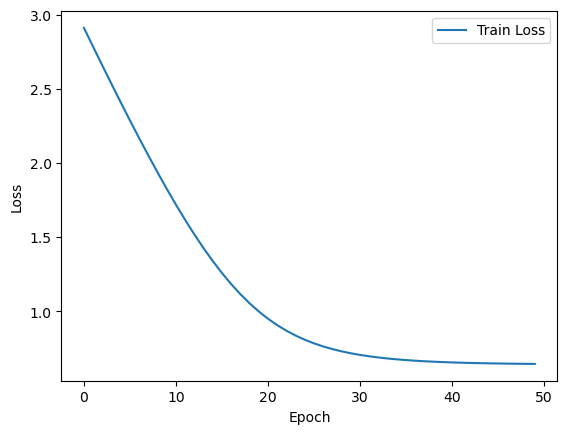

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Определяем класс для набора данных
class MarketingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values.astype(np.float32))  # Преобразуем данные в тип float32
        self.y = torch.tensor(y.values.astype(np.float32))  # Преобразуем целевую переменную в тип float32 для BCEWithLogitsLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Создаем объекты Dataset
X_train = pd.DataFrame({'feature1': [1.0, 2.0, 3.0], 'feature2': [4.0, 5.0, 6.0]})
y_train = pd.Series([0, 1, 0])
train_dataset = MarketingDataset(X_train, y_train)

# Создаем DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Определяем модель
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(input_size, 1)  # Один выходной нейрон, так как мы используем BCEWithLogitsLoss

    def forward(self, x):
        x = self.fc(x)
        return x

# Задаем параметры модели и оптимизатор
input_size = X_train.shape[1]
model = SimpleNN(input_size)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Обучаем модель
n_epochs = 50
train_losses = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)  # Прямой проход модели
        loss = criterion(outputs.squeeze(), targets)  # Вычисляем потери
        loss.backward()  # Обратное распространение
        optimizer.step()  # Шаг оптимизации

        running_loss += loss.item() * inputs.size(0)
    train_losses.append(running_loss / len(train_loader.dataset))

# Визуализируем кривую обучения
plt.plot(range(n_epochs), train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


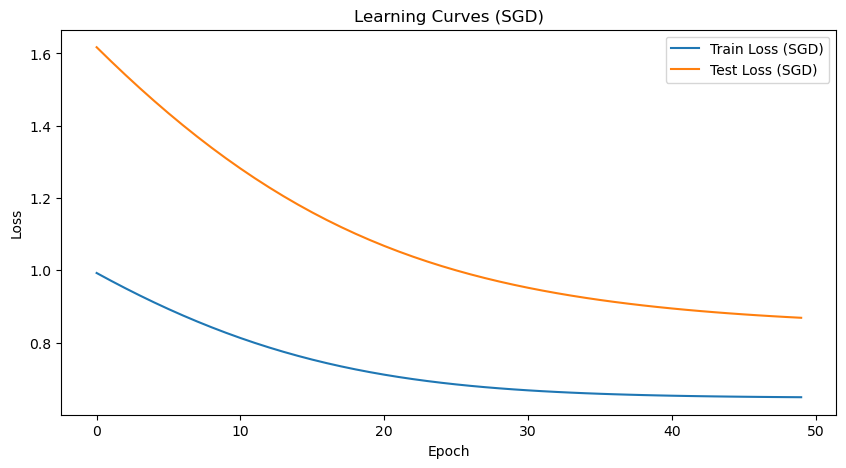

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Определяем класс для набора данных
class MarketingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values.astype(np.float32))  # Преобразуем данные в тип float32
        self.y = torch.tensor(y.values.astype(np.float32))  # Преобразуем целевую переменную в тип float32 для BCEWithLogitsLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Создаем объекты Dataset и DataLoader
X_train = pd.DataFrame({'feature1': [1.0, 2.0, 3.0], 'feature2': [4.0, 5.0, 6.0]})
y_train = pd.Series([0, 1, 0])
X_test = pd.DataFrame({'feature1': [1.5, 2.5], 'feature2': [4.5, 5.5]})
y_test = pd.Series([0, 1])

train_dataset = MarketingDataset(X_train, y_train)
test_dataset = MarketingDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Определяем модель SimpleNN_SGD
class SimpleNN_SGD(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN_SGD, self).__init__()
        self.fc = nn.Linear(input_size, 1)
    
    def forward(self, x):
        x = self.fc(x)
        return x

# Задаем параметры модели и оптимизатор
input_size = X_train.shape[1]  # Количество признаков в данных
model_sgd = SimpleNN_SGD(input_size)

criterion = nn.BCEWithLogitsLoss()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# Обучаем модель
n_epochs = 50
train_losses_sgd = []
test_losses_sgd = []

for epoch in range(n_epochs):
    model_sgd.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer_sgd.zero_grad()
        outputs = model_sgd(inputs.float()).squeeze()  # Преобразуем входные данные в тип float и убедимся, что они правильно передаются
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_sgd.step()
        running_loss += loss.item() * inputs.size(0)
    train_losses_sgd.append(running_loss / len(train_loader.dataset))
    
    model_sgd.eval()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model_sgd(inputs.float()).squeeze()
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
    test_losses_sgd.append(running_loss / len(test_loader.dataset))

# Визуализируем кривые обучения для модели с оптимизатором SGD
plt.figure(figsize=(10, 5))
plt.plot(range(n_epochs), train_losses_sgd, label='Train Loss (SGD)')
plt.plot(range(n_epochs), test_losses_sgd, label='Test Loss (SGD)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves (SGD)')
plt.show()


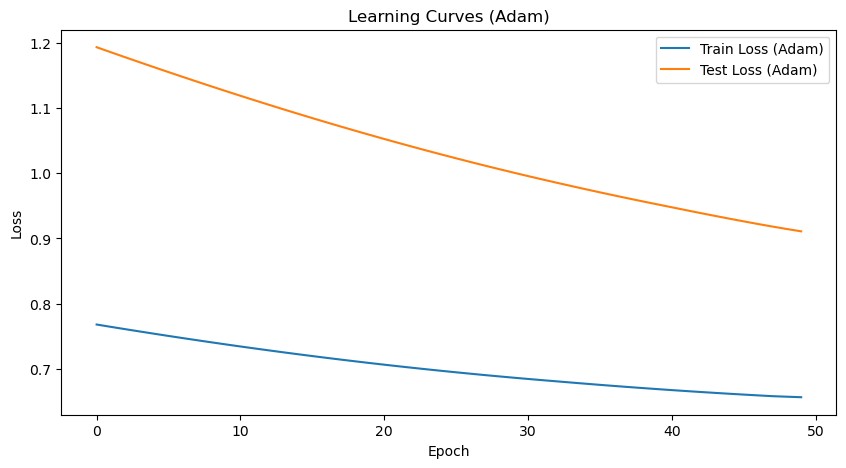

In [48]:
class SimpleNN_Adagrad(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN_Adagrad, self).__init__()
        self.fc1 = nn.Linear(input_size, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Задаем параметры модели и оптимизатор
model_adagrad = SimpleNN_Adagrad(input_size)

optimizer_adagrad = optim.Adam(model_adagrad.parameters(), lr=0.001)

# Обучаем модель
train_losses_adagrad = []
test_losses_adagrad = []

for epoch in range(n_epochs):
    model_adagrad.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer_adagrad.zero_grad()
        outputs = model_adagrad(inputs).squeeze()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_adagrad.step()
        running_loss += loss.item() * inputs.size(0)
    train_losses_adagrad.append(running_loss / len(train_loader.dataset))
    
    model_adagrad.eval()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model_adagrad(inputs).squeeze()
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
    test_losses_adagrad.append(running_loss / len(test_loader.dataset))

# Визуализируем кривые обучения для модели с оптимизатором Adam
plt.figure(figsize=(10, 5))
plt.plot(range(n_epochs), train_losses_adagrad, label='Train Loss (Adam)')
plt.plot(range(n_epochs), test_losses_adagrad, label='Test Loss (Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves (Adam)')
plt.show()


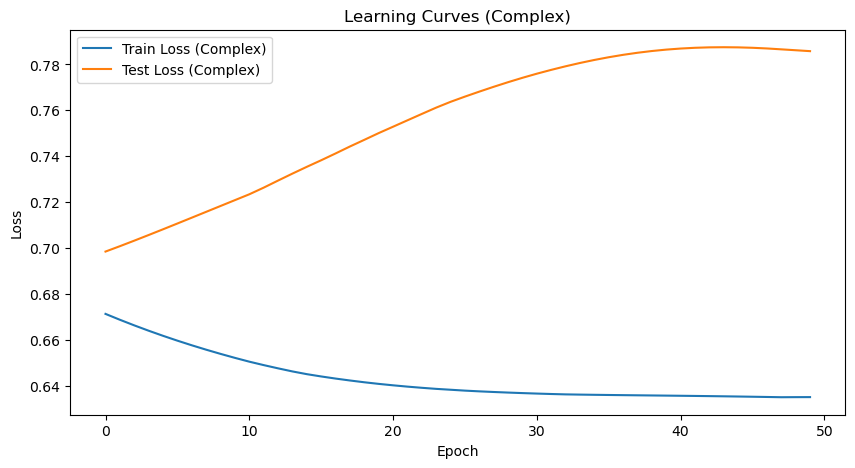

In [49]:
class ComplexNN(nn.Module):
    def __init__(self, input_size):
        super(ComplexNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, 1)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Задаем параметры модели и оптимизатор
model_complex = ComplexNN(input_size)

optimizer_complex = optim.Adam(model_complex.parameters(), lr=0.001)

# Обучаем модель
train_losses_complex = []
test_losses_complex = []

for epoch in range(n_epochs):
    model_complex.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer_complex.zero_grad()
        outputs = model_complex(inputs).squeeze()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_complex.step()
        running_loss += loss.item() * inputs.size(0)
    train_losses_complex.append(running_loss / len(train_loader.dataset))
    
    model_complex.eval()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model_complex(inputs).squeeze()
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
    test_losses_complex.append(running_loss / len(test_loader.dataset))

# Визуализируем кривые обучения для модели с несколькими слоями и оптимизатором Adam
plt.figure(figsize=(10, 5))
plt.plot(range(n_epochs), train_losses_complex, label='Train Loss (Complex)')
plt.plot(range(n_epochs), test_losses_complex, label='Test Loss (Complex)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves (Complex)')
plt.show()


In [54]:
import torch

def calculate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in data_loader:
            outputs = model(inputs).squeeze()  # Прямое распространение без сигмоиды, если это уже реализовано в модели
            predicted = (torch.sigmoid(outputs) >= 0.5).float()  # Применяем сигмоиду и пороговую функцию
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
    accuracy = correct / total
    return accuracy

# После обучения модели

# Вычисляем accuracy на тренировочных данных
train_accuracy = calculate_accuracy(model, train_loader)
print(f'Train Accuracy: {train_accuracy:.4f}')

# Вычисляем accuracy на тестовых данных
test_accuracy = calculate_accuracy(model, test_loader)
print(f'Test Accuracy: {test_accuracy:.4f}')


Train Accuracy: 0.6667
Test Accuracy: 0.5000
